In [1]:
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
from matplotlib.patches import Ellipse
import pandas as pd

# load LPT catalog
lpts = pd.read_csv('LPTs.csv', na_values='-')

### LPT distribution in the Galaxy

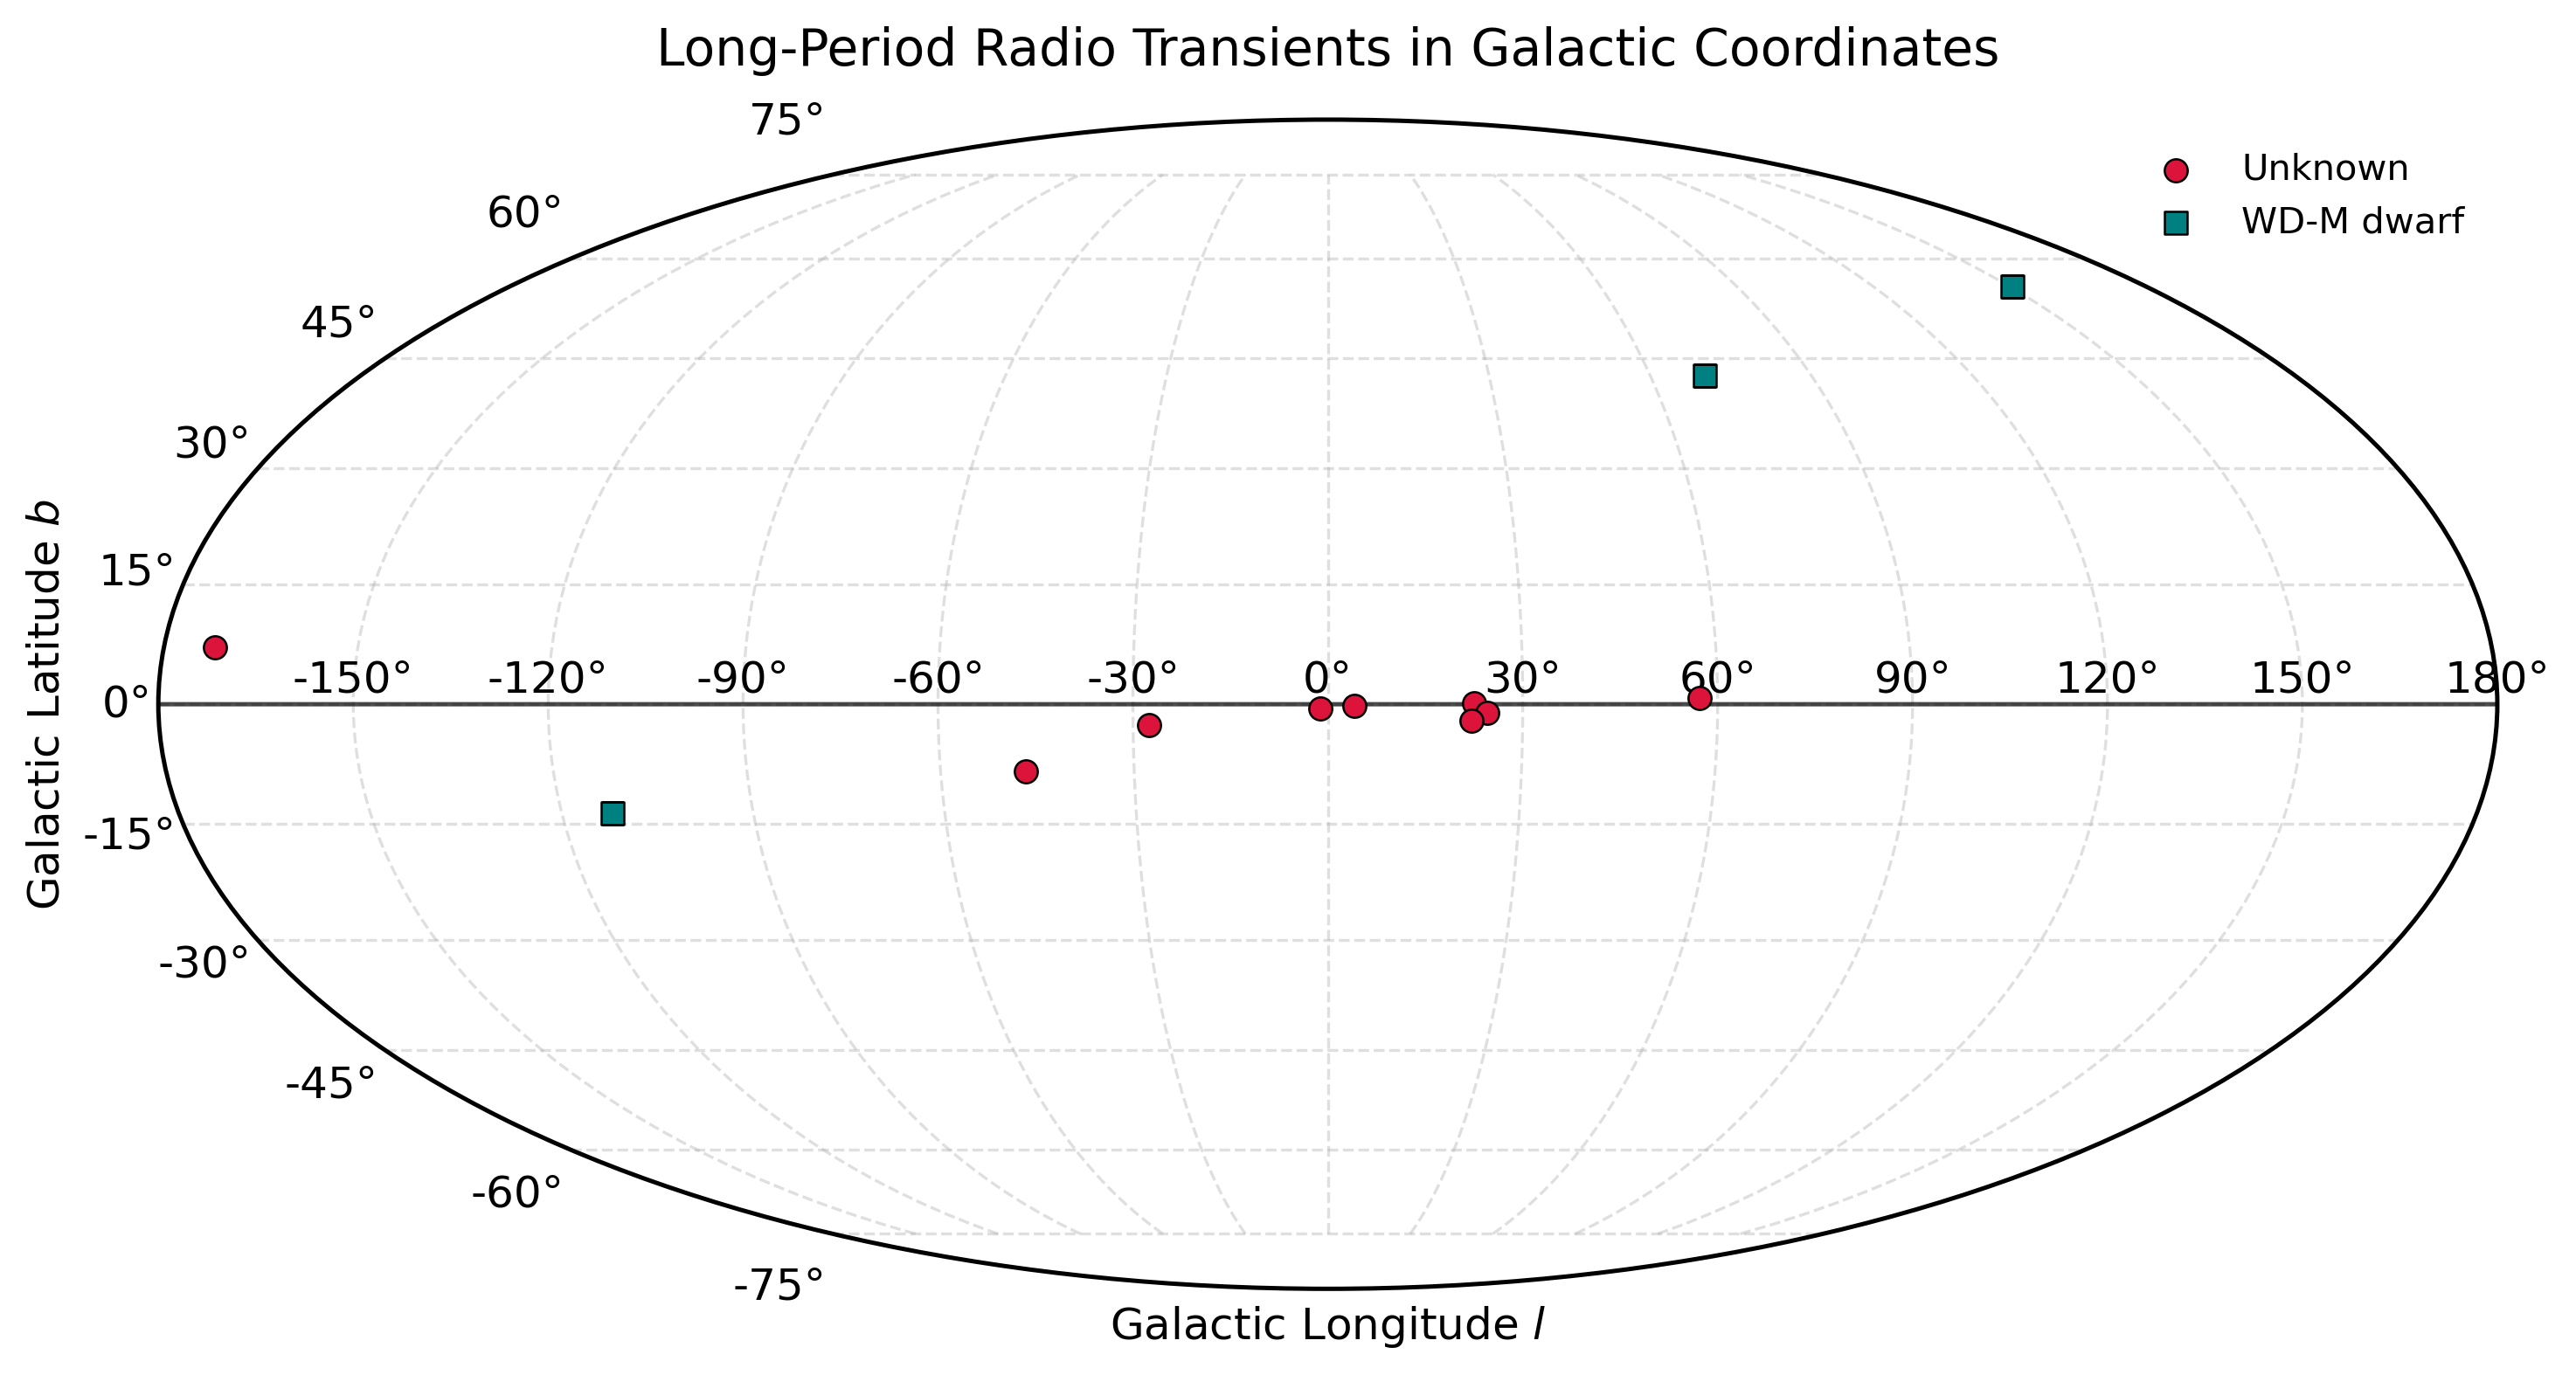

In [2]:
# =========================
# Input data
# =========================
l_deg = np.array(lpts['Gal_l (deg)'])
b_deg = np.array(lpts['Gal_b (deg)'])

l_err_deg = np.array(lpts['Gal_l_err'])
b_err_deg = np.array(lpts['Gal_b_err'])

# =========================
# Coordinate conversion
# =========================
# Wrap Galactic longitude to [-180, 180] for Mollweide
l_wrapped = ((l_deg + 180) % 360) - 180

l_rad = np.radians(l_wrapped)
b_rad = np.radians(b_deg)

l_err_rad = np.radians(l_err_deg)
b_err_rad = np.radians(b_err_deg)

# =========================
# Figure setup (publication-ready)
# =========================
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

fig, ax = plt.subplots(
    figsize=(10, 5.5),
    dpi=300,
    subplot_kw={"projection": "mollweide"}
)

# =========================
# Galactic plane
# =========================
l_plane = np.linspace(-180, 180, 1000)
b_plane = np.zeros_like(l_plane)

ax.plot(
    np.radians(l_plane),
    np.radians(b_plane),
    color="black",
    lw=1.2,
    alpha=0.7,
    # label="Galactic plane"
)

# Create a boolean mask where "binary" appears
notes = np.array(lpts['Notes'])
mask = np.array([isinstance(x, str) and "binary" in x for x in notes])

# Get indices
WD_idx = np.where(mask)[0]   # indices for WD-M dwarf binaries
unk_idx = np.where(mask==False)[0]   # indices for LPTs with unknown nature


# =========================
# Plot LPTs
# =========================
ax.scatter(
        l_rad[unk_idx], b_rad[unk_idx],
        s=40,
        color="crimson",
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
        label='Unknown'
    )

ax.scatter(
        l_rad[WD_idx], b_rad[WD_idx],
        marker='s',
        s=40,
        color="teal",
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
        label='WD-M dwarf'
    )

# =========================
# Plot LPTs + error ellipses
# =========================
# for i in range(len(l_rad)):
#     ax.scatter(
#         l_rad[i], b_rad[i],
#         s=40,
#         color="crimson",
#         edgecolor="black",
#         linewidth=0.6,
#         zorder=5
#     )

#     ellipse = Ellipse(
#         (l_rad[i], b_rad[i]),
#         width=2 * l_err_rad[i],
#         height=2 * b_err_rad[i],
#         edgecolor="gray",
#         facecolor="none",
#         lw=0.8,
#         alpha=0.6,
#         zorder=4
#     )
#     ax.add_patch(ellipse)

# =========================
# Formatting
# =========================
ax.grid(True, alpha=0.4, linestyle="--")

# Longitude tick labels in degrees
xticks = np.arange(-150, 181, 30)
ax.set_xticks(np.radians(xticks))
ax.set_xticklabels([f"{x}°" for x in xticks])

ax.set_xlabel(r"Galactic Longitude $l$")
ax.set_ylabel(r"Galactic Latitude $b$")

ax.set_title(
    "Long-Period Radio Transients in Galactic Coordinates",
    pad=15,
    fontsize=14
)

ax.legend(loc="upper right", bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize='small')

plt.tight_layout()
# plt.savefig('lpt_distribution.png')
plt.show()

### RM vs DM

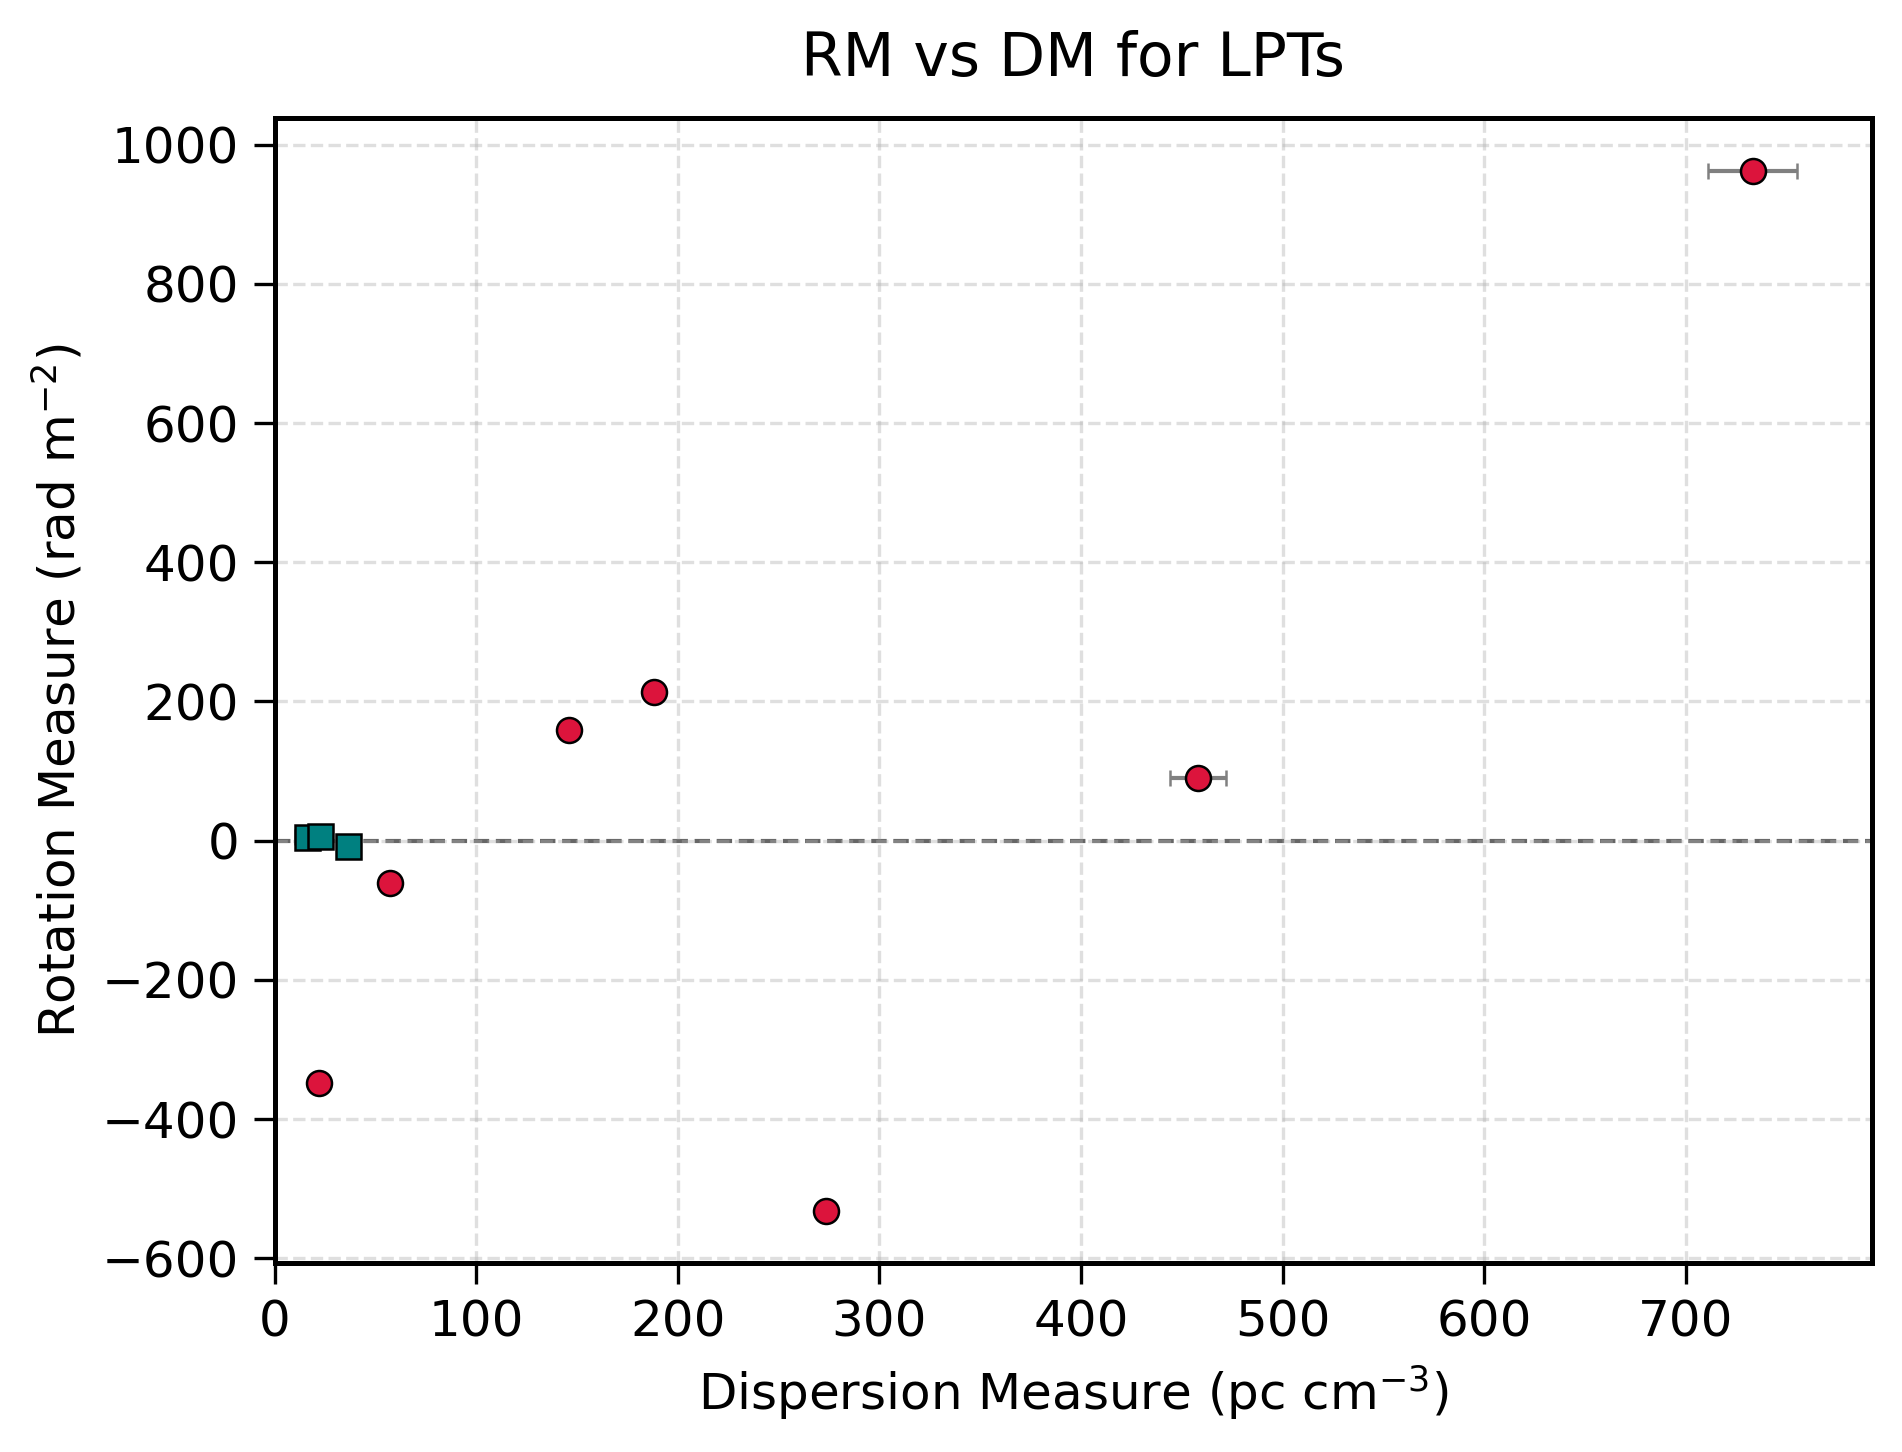

In [3]:
# =========================
# Input data
# =========================
DM = np.array(lpts['DM (pc/cm^3)'])
DM_err = np.array(lpts['DM_err'])

RM = np.array(lpts['RM (rad/m^2)'])
RM_err = np.array(lpts['RM_err'])

# =========================
# Figure setup
# =========================
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

fig, ax = plt.subplots(figsize=(6.5, 5), dpi=300)

# =========================
# Plot with error bars
# =========================
ax.errorbar(
    DM[unk_idx], RM[unk_idx],
    xerr=DM_err[unk_idx],
    yerr=RM_err[unk_idx],
    fmt='o',
    ms=6,
    color='crimson',
    ecolor='gray',
    elinewidth=1,
    capsize=2,
    markeredgecolor='black',
    markeredgewidth=0.6,
    zorder=3
)

ax.errorbar(
    DM[WD_idx], RM[WD_idx],
    xerr=DM_err[WD_idx],
    yerr=RM_err[WD_idx],
    fmt='s',
    ms=6,
    color='teal',
    ecolor='gray',
    elinewidth=1,
    capsize=2,
    markeredgecolor='black',
    markeredgewidth=0.6,
    zorder=3
)

# =========================
# Reference line RM = 0
# =========================
ax.axhline(0, color='black', lw=1, ls='--', alpha=0.6, zorder=1)

# =========================
# Labels & formatting
# =========================
ax.set_xlabel(r"Dispersion Measure (pc cm$^{-3}$)")
ax.set_ylabel(r"Rotation Measure (rad m$^{-2}$)")
ax.set_xlim([0, None])

ax.set_title("RM vs DM for LPTs", pad=10)

ax.grid(True, linestyle='--', alpha=0.4, zorder=0)

plt.tight_layout()
# plt.savefig('RMvsDM.jpeg')
plt.show()

### RM vs DM including pulsars

In [4]:
# Retrieve ATNF pulsar data via psrqpy
from psrqpy import QueryATNF
query = QueryATNF(params=['P0','P1', "GL", "GB", "DM", "RM", "ASSOC", "BINARY", "TYPE", "BinComp"])
df = query.table

DM_psr = df['DM']
RM_psr = df['RM']

# get only finite values
pidx = (np.isfinite(DM_psr)) & (np.isfinite(RM_psr))
DM_psr = DM_psr[pidx]
RM_psr = RM_psr[pidx]
GL = df['GL'][pidx]
GB = df['GB'][pidx]
# assocs = df["ASSOC"][pidx]  # associations
# types = df["TYPE"][pidx]  # pulsar types
# binaries = df["BINARY"][pidx]  # binary pulsars
# bincomps = df["BINCOMP"][pidx]  # binary companion types

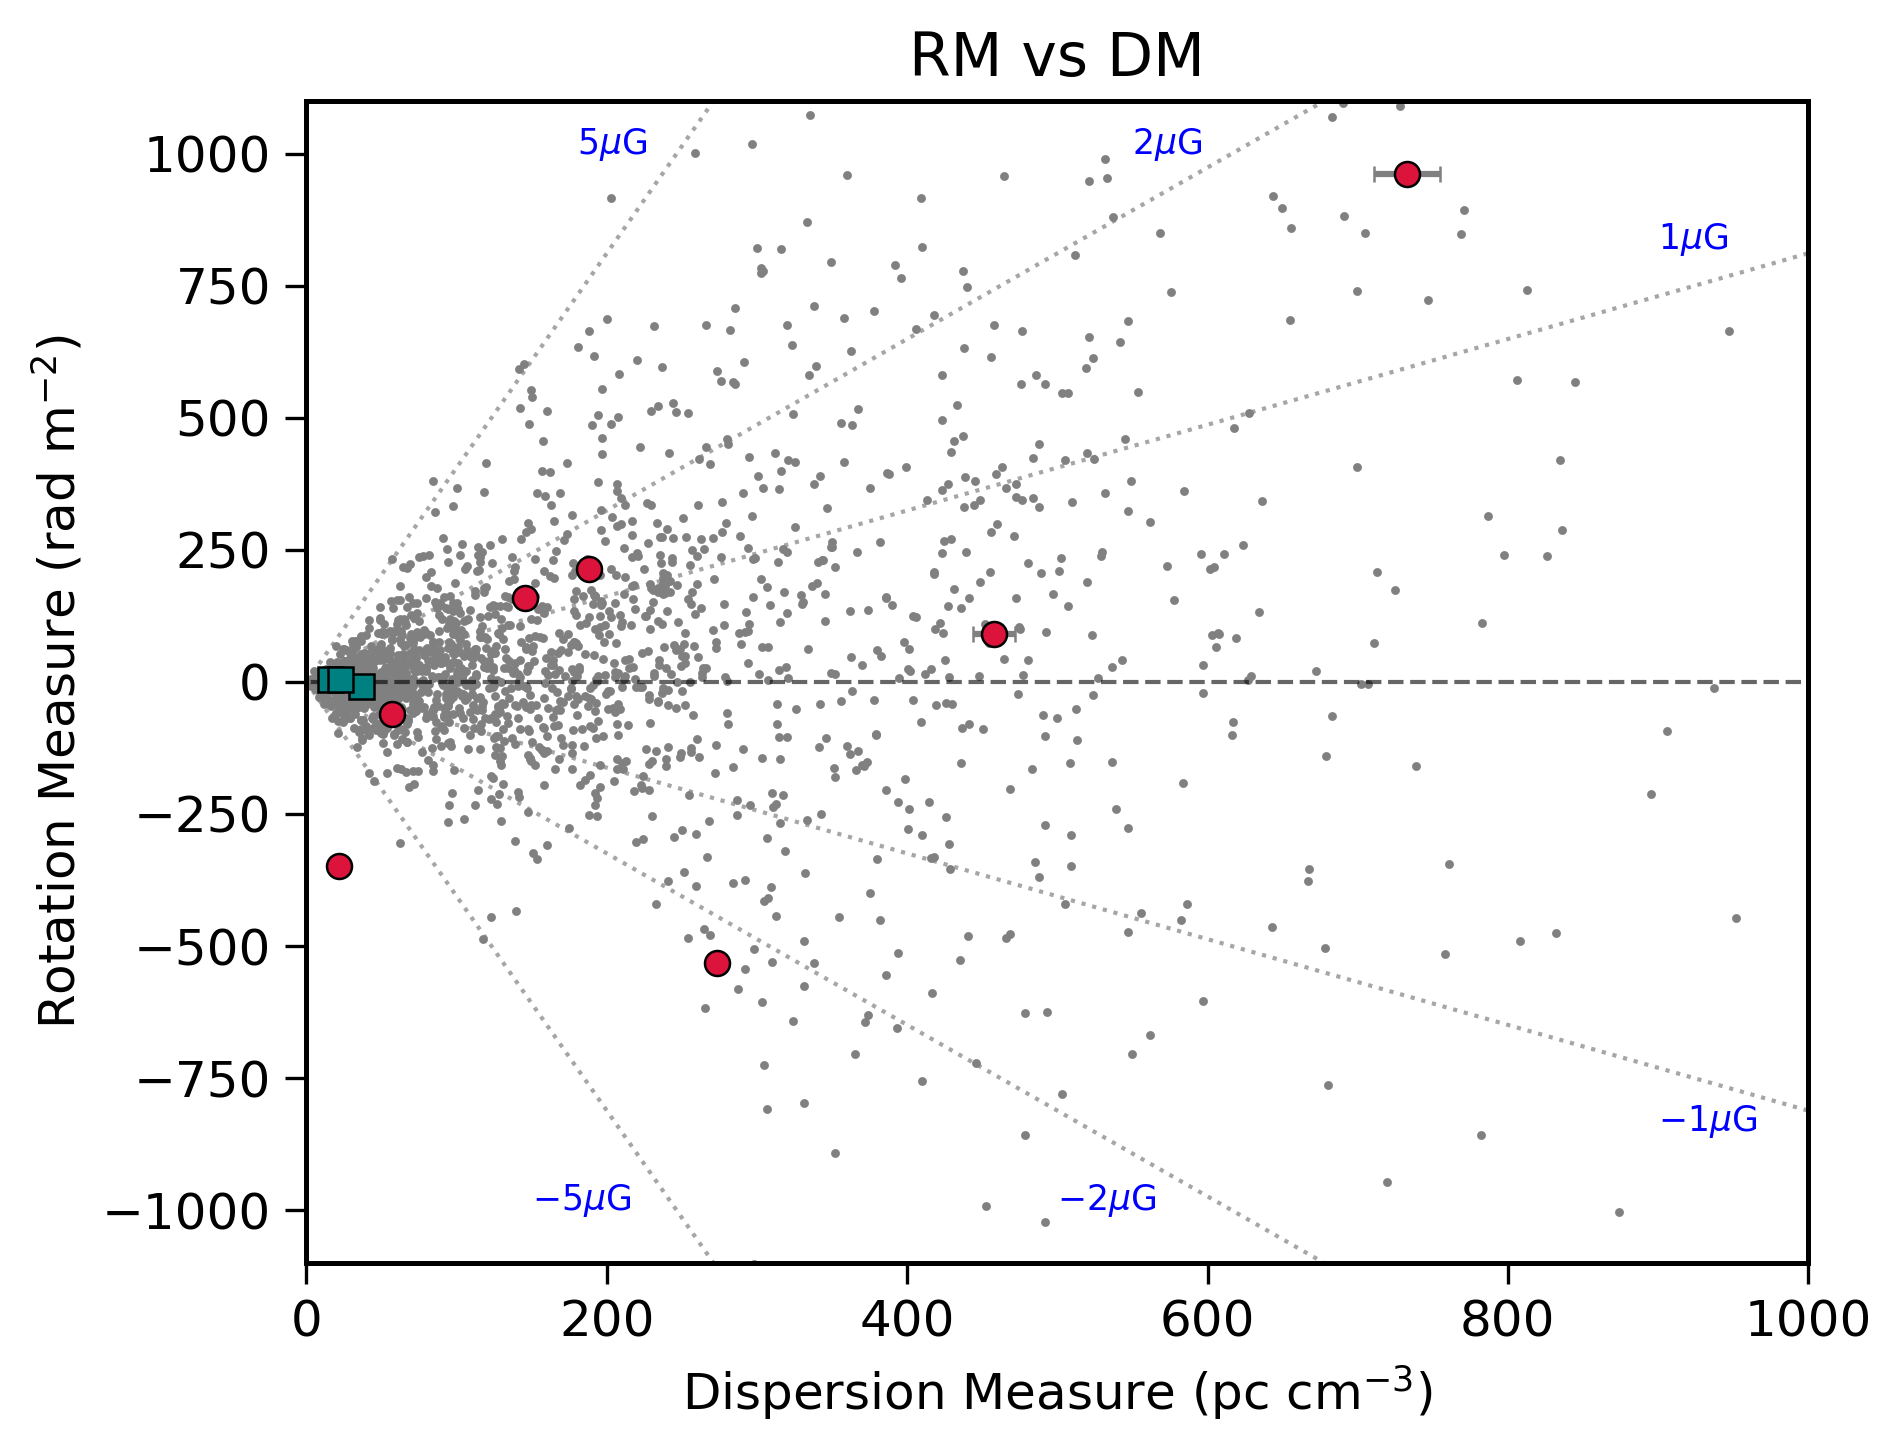

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=300)

# Pulsar Data
ax.scatter(
    DM_psr, RM_psr,
    marker='.',
    s=5,
    color='grey',
    zorder=1
)

# LPT Data
ax.errorbar(
    DM[unk_idx], RM[unk_idx],
    xerr=DM_err[unk_idx],
    yerr=RM_err[unk_idx],
    fmt='o',
    ms=6,
    color='crimson',
    ecolor='gray',
    capsize=2,
    markeredgecolor='black',
    markeredgewidth=0.6,
    zorder=3
)

ax.errorbar(
    DM[WD_idx], RM[WD_idx],
    xerr=DM_err[WD_idx],
    yerr=RM_err[WD_idx],
    fmt='s',
    ms=6,
    color='teal',
    ecolor='gray',
    capsize=2,
    markeredgecolor='black',
    markeredgewidth=0.6,
    zorder=3
)

# Zero line
ax.axhline(0, color='black', lw=1, ls='--', alpha=0.6)

# <B_parallel> lines
for B in [-5, -2, -1, 1, 2, 5]:
    DM_line = np.linspace(0, 1000, 500)
    RM_line = (B / 1.232) * DM_line
    ax.plot(DM_line, RM_line, color='gray', lw=1, ls=':', alpha=0.7)

ax.annotate(r'$-5 \mu {\rm G}$', (150, -1000), color='b', fontsize='x-small')
ax.annotate(r'$-2 \mu {\rm G}$', (500, -1000), color='b', fontsize='x-small')
ax.annotate(r'$-1 \mu {\rm G}$', (900, -850), color='b', fontsize='x-small')

ax.annotate(r'$5 \mu {\rm G}$', (180, 1000), color='b', fontsize='x-small')
ax.annotate(r'$2 \mu {\rm G}$', (550, 1000), color='b', fontsize='x-small')
ax.annotate(r'$1 \mu {\rm G}$', (900, 820), color='b', fontsize='x-small')

# Labels
ax.set_ylim([-1100,1100])
ax.set_xlim([0,1000])
ax.set_xlabel(r"Dispersion Measure (pc cm$^{-3}$)")
ax.set_ylabel(r"Rotation Measure (rad m$^{-2}$)")
# ax.set_title(r"RM vs DM for LPTs with $\langle B_\parallel \rangle$ Lines")
ax.set_title(r"RM vs DM")

# ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
# plt.savefig('RMvsDM_w_psr.png')
plt.show()

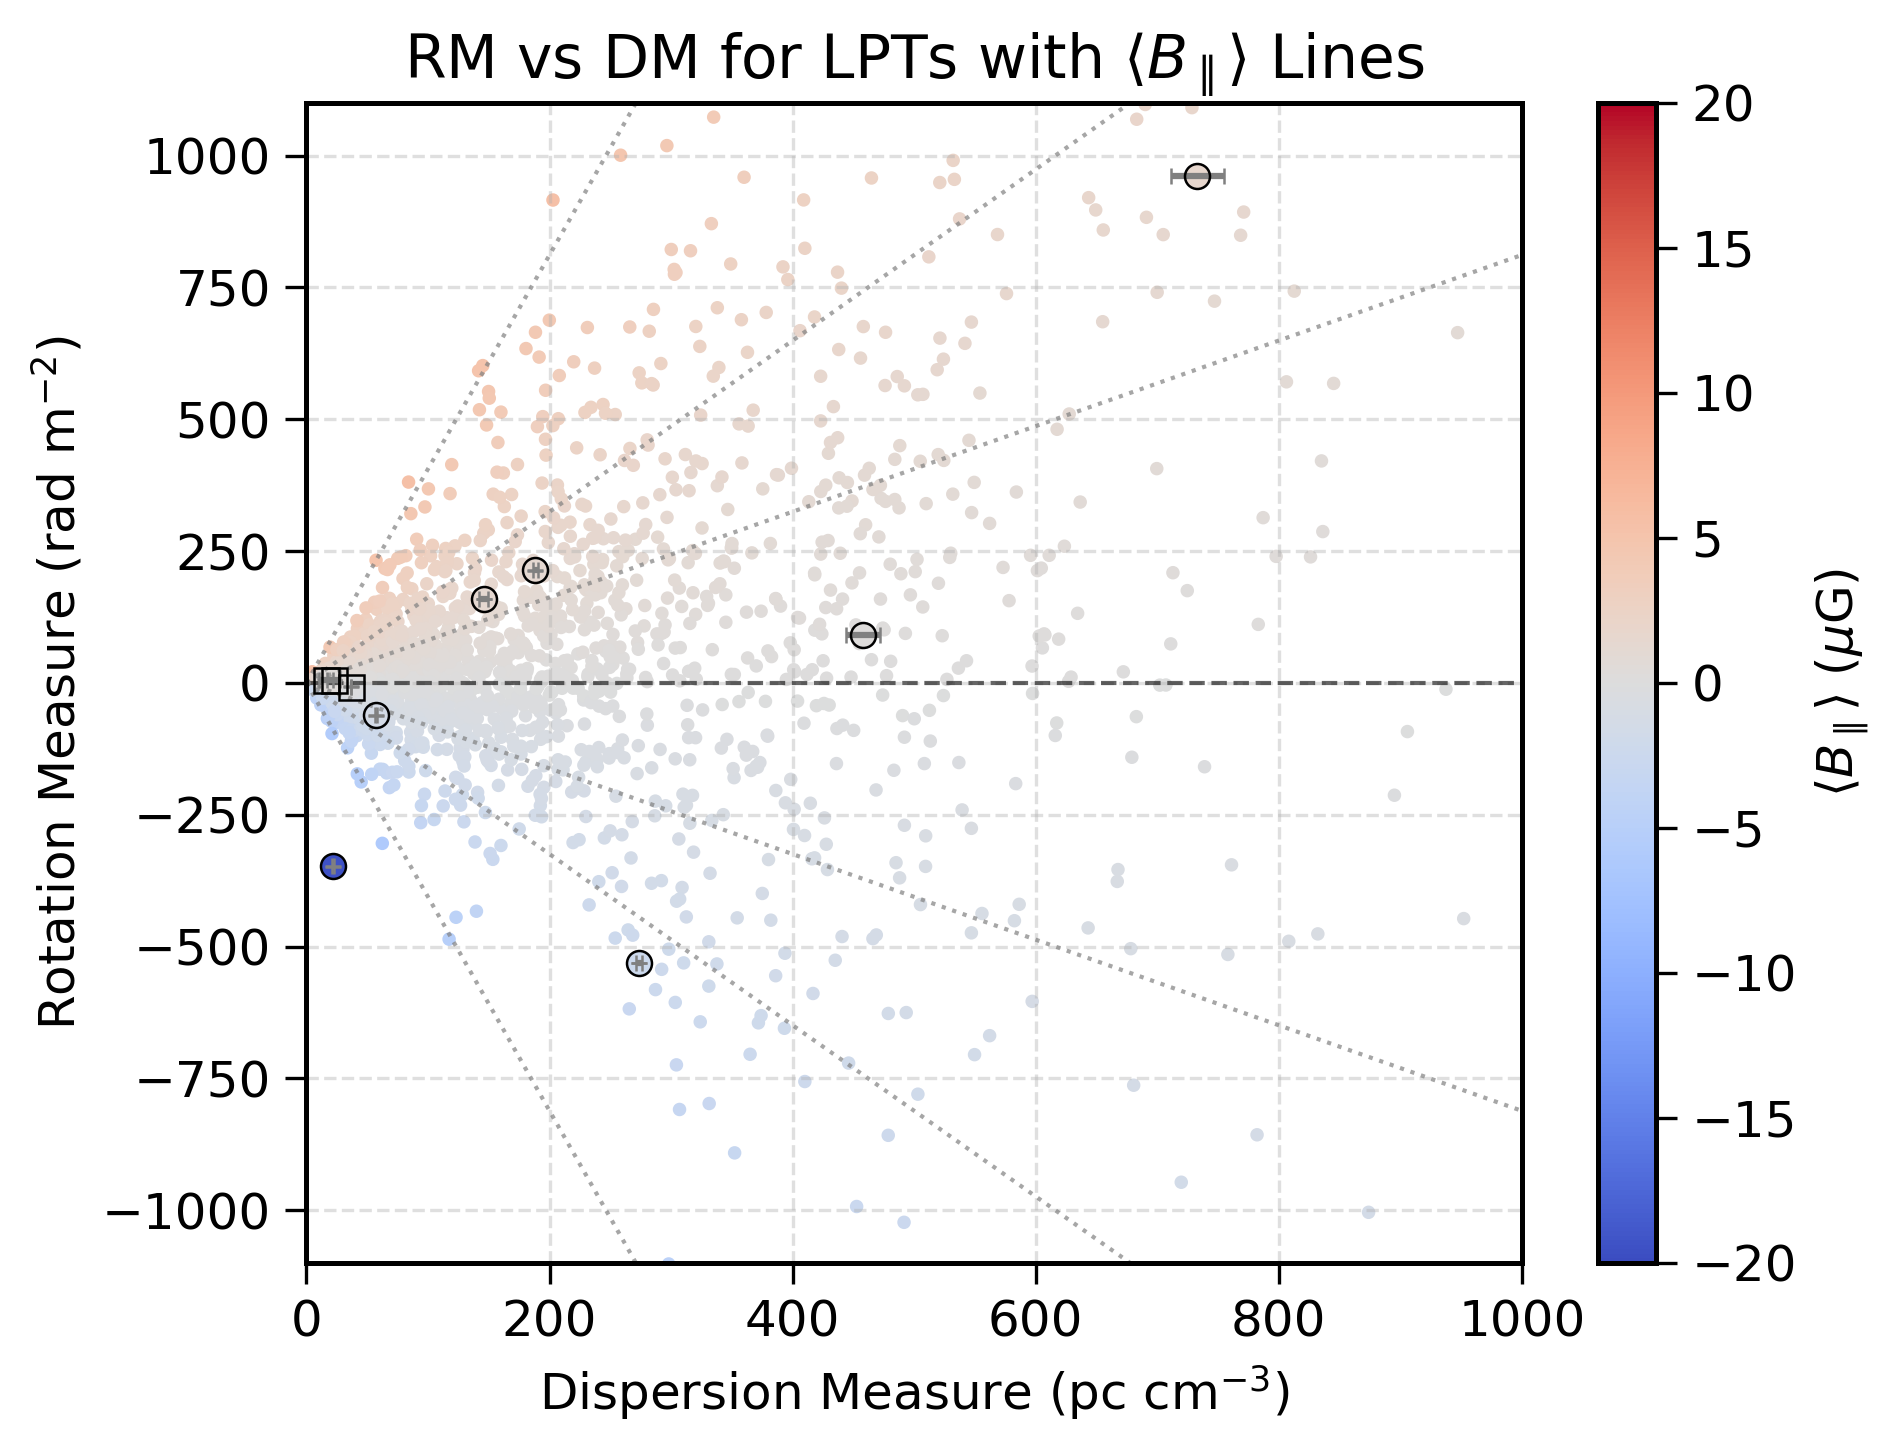

In [6]:
import matplotlib.colors as mcolors

dmmask = np.isfinite(DM) & np.isfinite(RM)

DM1 = DM[dmmask]
DM_err1 = DM_err[dmmask]
RM1 = RM[dmmask]
RM_err1 = RM_err[dmmask]

# Re-Create a boolean mask where "binary" appears
notes1 = notes[dmmask]
mask1 = np.array([isinstance(x, str) and "binary" in x for x in notes1])

# Get indices
WD_idx = np.where(mask1)[0]   # indices for WD-M dwarf binaries
unk_idx = np.where(mask1==False)[0]   # indices for LPTs with unknown nature

fig, ax = plt.subplots(figsize=(6.5, 5), dpi=300)

# Normalized color scale for both PSR and LPT
norm = mcolors.Normalize(vmin=-20, vmax=20)

# PSR background
B_para_psr = 1.232 * RM_psr / DM_psr

sc_psr = ax.scatter(
    DM_psr, RM_psr,
    c=B_para_psr,
    cmap='coolwarm',
    s=5,
    norm=norm,
    zorder=1
)

# LPT points
B_para_lpt = 1.232 * RM1 / DM1

sc_lpt = ax.scatter(
    DM1, RM1,
    c=B_para_lpt,
    cmap='coolwarm',
    s=36,
    edgecolor='none',
    norm=norm,
    zorder=1
)

# Error bars for LPTs
ax.errorbar(
    DM1[unk_idx], RM1[unk_idx],
    xerr=DM_err1[unk_idx],
    yerr=RM_err1[unk_idx],
    fmt='o',
    ms=6,
    color='none',
    ecolor='gray',
    capsize=2,
    markeredgecolor='black',
    markeredgewidth=0.6,
    zorder=3
)

ax.errorbar(
    DM1[WD_idx], RM1[WD_idx],
    xerr=DM_err1[WD_idx],
    yerr=RM_err1[WD_idx],
    fmt='s',
    ms=6,
    color='none',
    ecolor='gray',
    capsize=2,
    markeredgecolor='black',
    markeredgewidth=0.6,
    zorder=3
)

# Zero line
ax.axhline(0, color='black', lw=1, ls='--', alpha=0.6)

# <B_parallel> lines
for B in [-5, -2, -1, 1, 2, 5]:
    DM_line = np.linspace(0, 1000, 500)
    RM_line = (B / 1.232) * DM_line
    ax.plot(DM_line, RM_line, color='gray', lw=1, ls=':', alpha=0.7)

# Colorbar (single)
plt.colorbar(sc_lpt, label=r"$\langle B_\parallel \rangle$ ($\mu$G)")

# Labels and limits
ax.set_ylim([-1100,1100])
ax.set_xlim([0,1000])
ax.set_xlabel(r"Dispersion Measure (pc cm$^{-3}$)")
ax.set_ylabel(r"Rotation Measure (rad m$^{-2}$)")
ax.set_title(r"RM vs DM for LPTs with $\langle B_\parallel \rangle$ Lines")
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### P-Pdot diagram

In [7]:
periods = df['P0']
pdots = df['P1']

# get only finite values
pidx = (np.isfinite(periods)) & (np.isfinite(pdots))
periods = periods[pidx]
pdots = pdots[pidx]
assocs = df["ASSOC"][pidx]  # associations
types = df["TYPE"][pidx]  # pulsar types
binaries = df["BINARY"][pidx]  # binary pulsars
bincomps = df["BINCOMP"][pidx]  # binary companion types

# now get only positive pdot values
pidx = pdots > 0.0
periods = periods[pidx]
pdots = pdots[pidx]
assocs = assocs[pidx]
types = types[pidx]
binaries = binaries[pidx]
bincomps = bincomps[pidx]

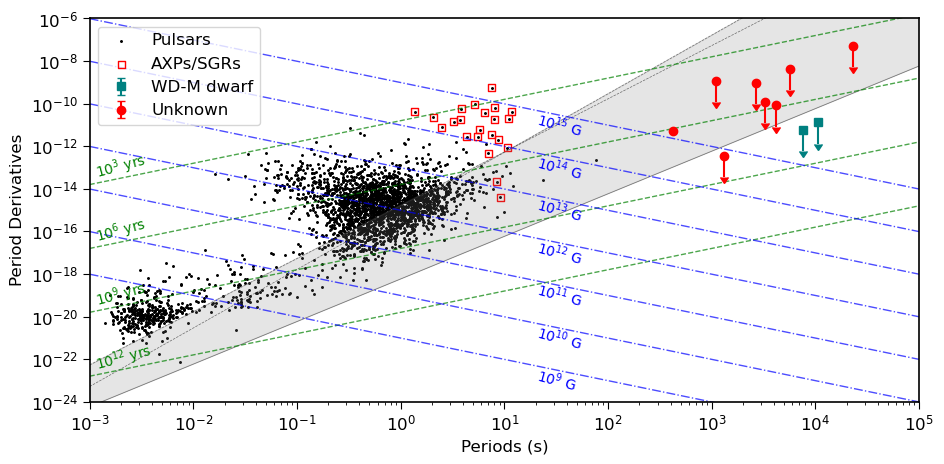

In [10]:
from astropy import constants

plt.figure(dpi=300, figsize=(6.4*7.5/5, 4.8))

B_surf = 3.2e+19 * np.sqrt(periods * pdots)

# plot pulsars
plt.scatter(periods, pdots, marker=".", color="k", s=5, label='Pulsars')
# sc = plt.scatter(periods, pdots, marker=".", s=10, c=B_surf, norm=LogNorm(), cmap='viridis', label='Pulsars')

# highlight additional types
# types = ['', nan, 'AXP', 'HE', 'NRAD', 'RRAT', 'XINS']
# assocs = [nan, 'EXGAL', 'GC', 'GRS', 'OPT', 'PWN', 'SNR', 'XRS']
# bincomps = [nan, 'CO', 'He', 'HeT', 'MS', 'NS', 'UL', 'ULT']

magnetar_idx = np.where(types=='AXP')
plt.scatter(periods[magnetar_idx], pdots[magnetar_idx], marker="s", color="r", facecolor='none',
           s=25, label='AXPs/SGRs')

# add colorbar
# plt.colorbar(sc, label='Surface B-field (G)')

# --- Age lines (characteristic age τ = P / (2 Pdot)) ---
age_list_years = np.array([1e3, 1e6, 1e9, 1e12])
sec = 365.25 * 24 * 3600
P_line = np.logspace(-3, 5, 200)

for age_yr in age_list_years:
    tau = age_yr * sec
    Pdot_line = P_line / (2 * tau)
    plt.plot(P_line, Pdot_line, '--', color='green', linewidth=1, alpha=0.7)

    # label: 10^N yrs
    N = int(np.log10(age_yr))
    label = rf"$10^{{{N}}}$ yrs"
    
    plt.text(0.0012, 0.002 / (2 * tau), label, fontsize=10, color='green', rotation=15, rotation_mode='anchor')

# --- B-field lines (B_surf = 3.2e+19 * np.sqrt(periods * pdots) ) ---
B_fields = np.logspace(9, 15, 7)

for B in B_fields:
    Pdot_B_line = (B / 3.2e+19)**2 / P_line
    plt.plot(P_line, Pdot_B_line, '-.', color='b', linewidth=1, alpha=0.7)

    N = int(np.log10(B))
    label = rf"$10^{{{N}}}$ G"

    plt.text(20, (B / 3.2e+19)**2 / 100, label, fontsize=10, color='b', rotation=-15, rotation_mode='anchor')

############# death lines #############
light_c_cgs = constants.c.cgs.value
R_NS6 = 1.2
R_NS = 1.2*1.e6
Msolar = 2*1.e33
M_NS = 1.4*Msolar
K = 4 * (3 * light_c_cgs**3) * 2 / (5 * 8 * np.pi**2)

xx = np.logspace(-3, 6, 3000)
# pure dipole - Chen et al.
chen1_ppdot_pd = 1/K * ((2.2*1.e12 * (R_NS6)**(-19/8) * xx**(15/8))**2) * (R_NS)**4 / M_NS  / xx
plt.plot(xx,chen1_ppdot_pd, linestyle='dashed', color='black', alpha=0.6, lw=0.5, zorder=-1)
# pure dipole - Zhang et al.
zhangIII_ppdot = 1/K * ((9.2*1.e25 * (R_NS)**(-9/4) * xx**(7/4))**2) * (R_NS)**4 / M_NS  / xx
plt.plot(xx,zhangIII_ppdot, linestyle='dashed', color='black', alpha=0.6, lw=0.5, zorder=-1)
# multipolar with beta=10
beta = 10
chen4_ppdot_tw_multi = 1/K * ((9.2*1.e10 * beta**(-1/4) * (R_NS6)**(-2) * xx**(3/2))**2) * (R_NS)**4 / M_NS  / xx
plt.plot(xx,chen4_ppdot_tw_multi, linestyle='solid', color='black', alpha=0.6, lw=0.5, zorder=-1)
### fill death valley
plt.fill_between(xx, chen4_ppdot_tw_multi, np.maximum(chen1_ppdot_pd, zhangIII_ppdot), color='grey', alpha=0.2)


########### LPT data ##########

LPT_P_min = np.array(lpts['Period (min)'])
LPT_P = LPT_P_min * 60  # convert minutes to seconds

LPT_Pdot = np.array(lpts['Pdot (s/s)'])
LPT_Pdot_err = np.array(lpts['Pdot_err'])
LPT_Pdot_ul = np.array(lpts['Pdot_ul'])  

# get mask for pdot

pdotmask = np.isfinite(LPT_Pdot) & np.isfinite(LPT_P)

LPT_Pdot = LPT_Pdot[pdotmask]
LPT_P = LPT_P[pdotmask]
LPT_Pdot_err = LPT_Pdot_err[pdotmask]
LPT_Pdot_ul = LPT_Pdot_ul[pdotmask]
notes1 = notes[pdotmask]

pdotmask = LPT_Pdot>0

LPT_Pdot = LPT_Pdot[pdotmask]
LPT_P = LPT_P[pdotmask]
LPT_Pdot_err = LPT_Pdot_err[pdotmask]
LPT_Pdot_ul = LPT_Pdot_ul[pdotmask]
notes1 = notes1[pdotmask]

# Re-Create a boolean mask where "binary" appears
mask1 = np.array([isinstance(x, str) and "binary" in x for x in notes1])

# Get indices
WD_idx = np.where(mask1)[0]   # indices for WD-M dwarf binaries
unk_idx = np.where(mask1==False)[0]   # indices for LPTs with unknown nature

# WD-M dwarf LPTs & Pdot upper limits
tmp = mask1 & LPT_Pdot_ul
tmp = tmp.astype(bool)
plt.errorbar(LPT_P[tmp], LPT_Pdot[tmp], yerr=LPT_Pdot[tmp]*0.9, uplims=True, fmt='s', color='teal', label='WD-M dwarf')

# WD-M dwarf LPTs & known Pdot
tmp = mask1 & ~LPT_Pdot_ul
tmp = tmp.astype(bool)
plt.errorbar(LPT_P[tmp], LPT_Pdot[tmp], yerr=LPT_Pdot_err[tmp], color='teal', marker='s', )

# Unknown LPTs & Pdot upper limits
tmp = ~mask1 & LPT_Pdot_ul
tmp = tmp.astype(bool)
plt.errorbar(LPT_P[tmp], LPT_Pdot[tmp], yerr=LPT_Pdot[tmp]*0.9, uplims=True, fmt='o', color='red', label='Unknown')

# Unknown LPTs & known Pdot
tmp = ~mask1 & ~LPT_Pdot_ul
tmp = tmp.astype(bool)
plt.errorbar(LPT_P[tmp], LPT_Pdot[tmp], yerr=LPT_Pdot_err[tmp], color='red', marker='o', )

plt.xlabel(r"Periods (s)")
plt.ylabel(r"Period Derivatives")
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e-3,1e+5])
plt.ylim([1e-24, 1e-6])
plt.legend(loc=2)
plt.tight_layout()
# plt.savefig('PPdot_with_LPTs.png')